# Granite for Bike Rental Predictions

This notebook leverages GRANITE to yield regional explanations on the BikeSharing dataset.
## Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from joblib import dump, load

# Local imports
from granite.data import get_data_bike

/Users/max/miniconda3/envs/GRANITE/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [2]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_bike()
# Make months and weekdays smaller for the plots (optional)
features.feature_objs[1].cats = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
features.feature_objs[4].cats = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
features.summary()
cat_features = [0, 1, 3, 4, 5, 6]

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | yr                 | ordinal            | 2          | [0]              |
| 1 | mnth               | ordinal            | 12         | [1]              |
| 2 | hr                 | num_int            | 24         | [2]              |
| 3 | holiday            | bool               | 2          | [3]              |
| 4 | weekday            | ordinal            | 7          | [4]              |
| 5 | workingday         | bool               | 2          | [5]              |
| 6 | weathersit         | num_int            | 4          | [6]              |
| 7 | temp               | num                | inf        | [7]              |
| 8 | hum                | num                | inf        | [8]              |
| 9 | windspeed          | num                | inf        | [9]              |
----------------------------------------

This dataset involves 10 features of various types. The following Table can help understand their meaning and domain.

<p align="center">
    <img src="./Images/Features_bike.png" width="600">
</p>

### Fitting the model
Having fetched the data, we fit a `HistGradientBoostingRegressor`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

**Do not run the following cells if you have already trained the model. Skip to later cells.**

In [4]:
grid = {"learning_rate": np.logspace(-2, 0, 10),
        "max_depth" : [3, 4, 5, 6, 7],
        "max_iter" : [50, 100, 150, 200],
        'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

search = RandomizedSearchCV(
    model,
    cv=KFold(),
    scoring='neg_root_mean_squared_error',
    param_distributions=grid,
    verbose=2,
    n_iter=20,
    random_state=42
)
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.5s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.4s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.5s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.4s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.4s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.3593813

,estimator,HistGradientB...andom_state=0)
,param_distributions,"{'learning_rate': array([0.01 ..., 1. ]), 'max_depth': [3, 4, ...], 'max_iter': [50, 100, ...], 'min_samples_leaf': [1, 20, ...]}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [5]:
# Recover the optimal CV model
model = search.best_estimator_
res = search.cv_results_
cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
best_idx = np.argmin(cv_perf)

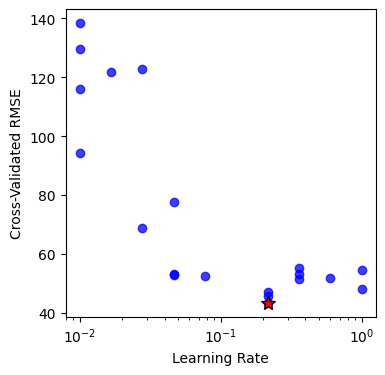

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(res['param_learning_rate'], cv_perf, c='b', alpha=0.75)
plt.plot(res['param_learning_rate'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validated RMSE")
plt.xscale('log')
plt.show()

In [7]:
# Pickle the model
dump(model, os.path.join("models", "bike_gbt.joblib"))

['models/bike_gbt.joblib']

**Start from here if you have already trained and dumped the model.**

In [8]:
# Load the model
model = load(os.path.join("models", "bike_gbt.joblib"))
test_preds = model.predict(X_test)
print(f" RMSE of the model : {root_mean_squared_error(test_preds, y_test):.2f}")
print(f" Std dev of the target : {y_test.std():.2f}")

 RMSE of the model : 43.08
 Std dev of the target : 181.45


## Computing Marginal Pure-Full Effects

We can understand how an individual features impact the model response by computing their pure and full marginal effects.
We first compute the Anchored decomposition.

In [9]:
from granite.decompositions import get_components_tree
# Compute the H^k matrices using a subset of 1000 training points
background = X_train[:1000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)

/Users/max/PycharmProjects/GRANITE/granite/decompositions.py:27: SyntaxWarning: invalid escape sequence '\m'
  .. math:: h_{i,\mathcal{B}}(x_i)  = h_i(x_i) - \mathbb{E}_{z\sim\mathcal{B}}[h_i(z_i)]
/Users/max/PycharmProjects/GRANITE/granite/decompositions.py:218: SyntaxWarning: invalid escape sequence '\s'
  h_{u,z}(x_u) = \sum_{v\subseteq u} (-1)^{|u|-|v|} h(x_v, z_{-v})
/Users/max/PycharmProjects/GRANITE/granite/decompositions.py:302: SyntaxWarning: invalid escape sequence '\s'
  h_{u,z}(x_u) = \sum_{v\subseteq u} (-1)^{|u|-|v|} h(x_v, z_{-v})
/Users/max/PycharmProjects/GRANITE/granite/decompositions.py:415: SyntaxWarning: invalid escape sequence '\m'
  h_{i,\mathcal{B}}(x_i) = \mathbb{E}_{z\sim \mathcal{B}} [h_{i,z}(x_i)]
/Users/max/PycharmProjects/GRANITE/granite/decompositions.py:596: SyntaxWarning: invalid escape sequence '\P'
  \Phi^{PDP}_i(h) = \mathbb{E}_{x\sim \mathcal{F}} [ h_{i,\mathcal{B}}(x_i)^2]
/Users/max/PycharmProjects/GRANITE/granite/decompositions.py:760: SyntaxWarn

###] 100%

In [10]:
# The keys are tuples encoding subsets of features
display(decomposition.keys())
# The () key is the intercept
display(decomposition[()].shape)
# The key (i,) is the main effect of feature i in the Anchored Decomposition
display(decomposition[(0,)].shape)

dict_keys([(), (0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,), (9,)])

(1000,)

(1000, 1000)

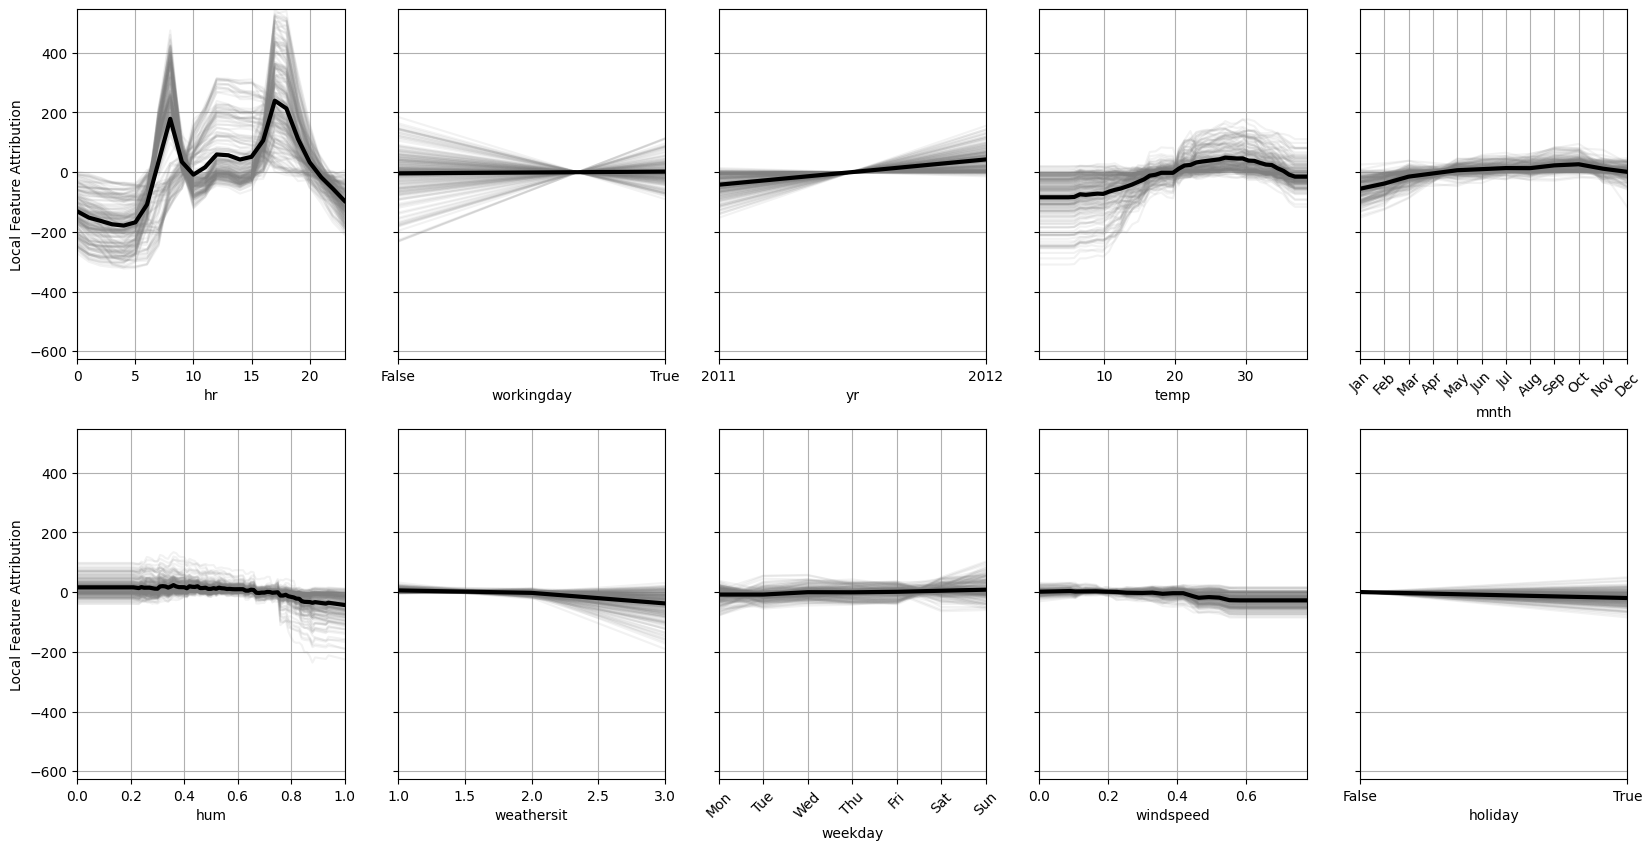

In [11]:
from granite.plots import partial_dependence_plot

# Plot the PDP and the ICE curves
partial_dependence_plot(decomposition, background, features, centered=True, figsize=(20, 10))
plt.show()

In this plot, the dark line is the PDP while the thin lines are the ICEs. Difference between the two are indicators of feature interactions.
This means that the effects of increasing/decreasing feature values depends on the state of other features. Local explanations should account for these interactions.

We shall minimize all pure-vs-full effect and interactions within a subset $U\subseteq 2^{[d]}$ where $2^{[d]}$ is the powerset. Fixing $U=\{\{0\}, \{1\}, \ldots \{d\}\}$ will minimize all
interactions, while $U=\{\{7\}\}$ will minimize all interactions involving feature $7$. In the future, we could envision using $U=\{\{0, 1\}\}$ to mimimize all interactions that a struct supersets
of $\{0, 1\}$, which would lead to pure pairwise interactions that are faithful to the model.

In [12]:
from granite.experiments import MinimizeSuperset

# Option 1: We minimize all interactions
U = [(i,) for i in range(len(features))]
features_to_split_upon = [i for i in range(len(features))]

# # Option 2: We minimize all interactions involving `temp`
# U = [(7,)]
# features_to_split_upon = [i for i in range(len(features)) if not i == 7]

# We penalize all pure-vs-full effects of each feature, which ammounts to minimizing all interactions within the model
tree = MinimizeSuperset(max_depth=3, features=features.select(features_to_split_upon), alpha=0.1, save_losses=True)
tree.fit(background[:, features_to_split_upon], decomposition, U=U)
tree.print(verbose=True)

/Users/max/PycharmProjects/GRANITE/granite/fd_trees.py:12: SyntaxWarning: invalid escape sequence '\,'
  {"leq" : "$\,\leq\,$",
/Users/max/PycharmProjects/GRANITE/granite/fd_trees.py:13: SyntaxWarning: invalid escape sequence '\,'
  "and_str" : "$)\,\,\land$\,\,(",
/Users/max/PycharmProjects/GRANITE/granite/fd_trees.py:14: SyntaxWarning: invalid escape sequence '\,'
  "up" : "$\,>\,$",
/Users/max/PycharmProjects/GRANITE/granite/fd_trees.py:15: SyntaxWarning: invalid escape sequence '\,'
  "low" : "$\,<\,$",
/Users/max/PycharmProjects/GRANITE/granite/fd_trees.py:16: SyntaxWarning: invalid escape sequence '\i'
  "in_set" : "$\in$"},


Loss 0.8942
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.1493
|   Samples 328
|   Region 0
else:
|   Loss 0.3151
|   Samples 672
|   If hr ≤ 6.0000:
|   |   Loss 0.0040
|   |   Samples 190
|   |   Region 1
|   else:
|   |   Loss 0.1937
|   |   Samples 482
|   |   Region 2
Final Loss 0.3470


In [13]:
# Using regional backgrounds
larger_background = X[:4000]
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

(array([0, 1, 2], dtype=int32), array([1254,  795, 1951]))
{0: 'not workingday', 1: '(workingday & hr<=6.00)', 2: '(workingday & hr>6.00)'}


In [14]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_shap = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    anchored=True)

[##################################################] 100%[                                                  ] 0%

##################################################] 100%[                                                  ] 0%

###############################################   ] 94%

####] 100%

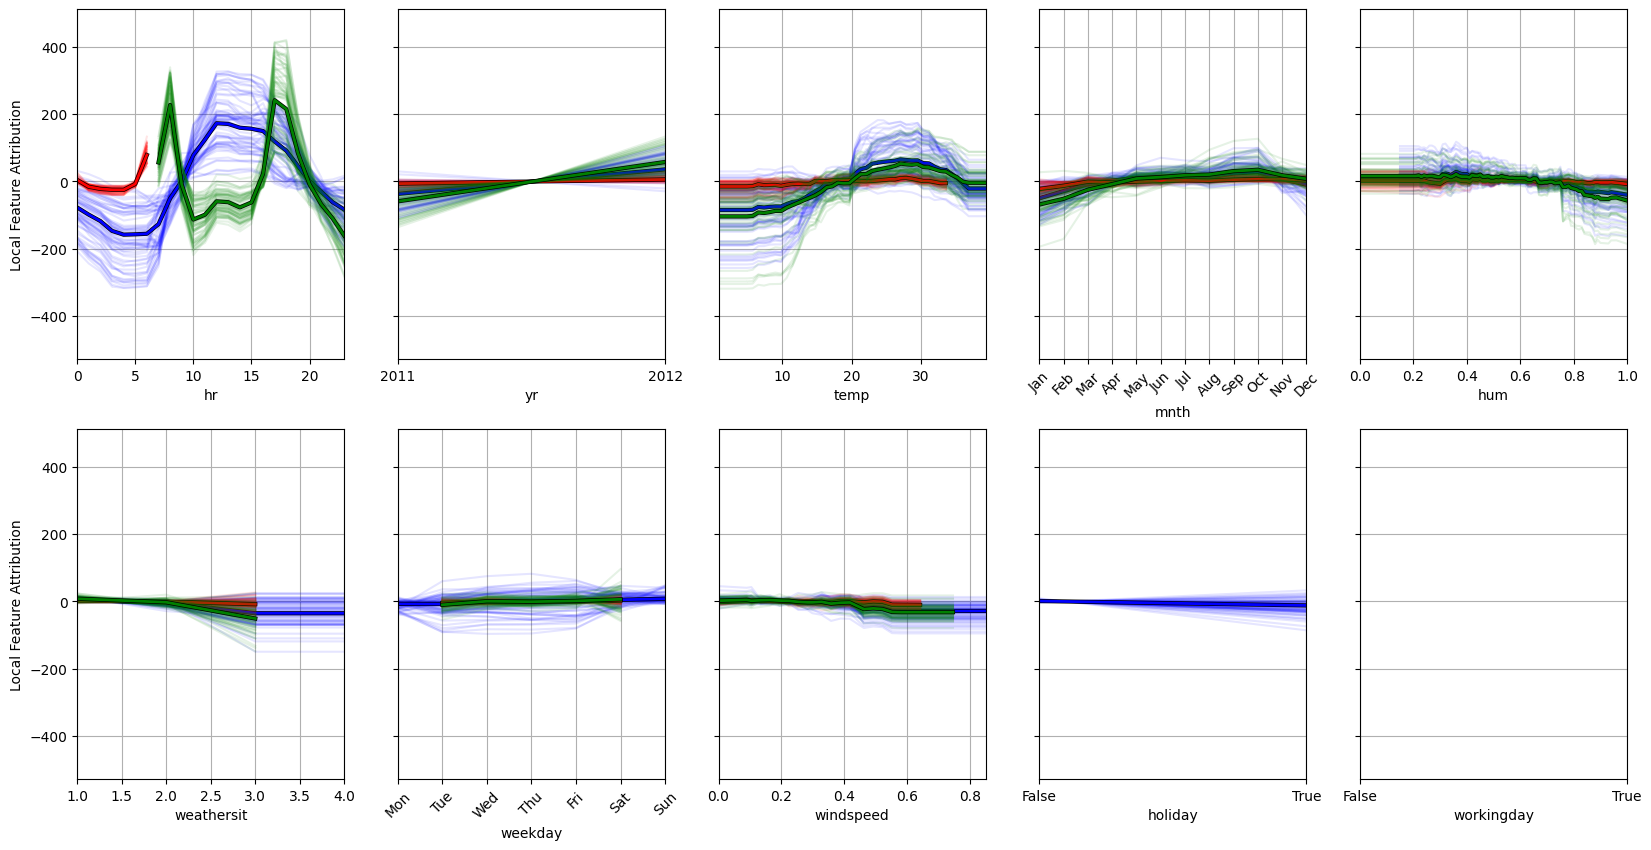

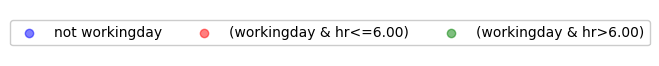

In [15]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, centered=True, figsize=(20, 10))
plot_legend(rules, ncol=4)
plt.show()

## Computing Marginal and Conditional Effects

**TODO generalize this code to work with feature subsets instead of one feature at a time.**

In [16]:
# create bins for all features
from granite.utils import create_bins_for_data

_, binned_features = create_bins_for_data(
    x=background,
    cat_feature_indices=cat_features,
    n_bins_numerical=5,
)

for i, bins in enumerate(binned_features):
    print(f"Feature {i}: Binned Indices Sample = {binned_features[i][:10]}")


Feature 0: Binned Indices Sample = [0 0 0 0 0 0 0 0 0 0]
Feature 1: Binned Indices Sample = [ 5  2  9  5  7  2 10  6  8  9]
Feature 2: Binned Indices Sample = [4 0 1 0 0 4 3 4 1 2]
Feature 3: Binned Indices Sample = [0 0 0 0 0 0 0 0 0 0]
Feature 4: Binned Indices Sample = [4 5 4 5 5 2 5 4 4 2]
Feature 5: Binned Indices Sample = [0 0 0 0 0 0 0 0 0 0]
Feature 6: Binned Indices Sample = [0 1 0 0 0 0 0 0 1 1]
Feature 7: Binned Indices Sample = [3 1 2 3 3 0 1 3 3 3]
Feature 8: Binned Indices Sample = [0 4 4 2 3 2 4 2 4 3]
Feature 9: Binned Indices Sample = [3 3 3 0 2 2 1 3 1 1]


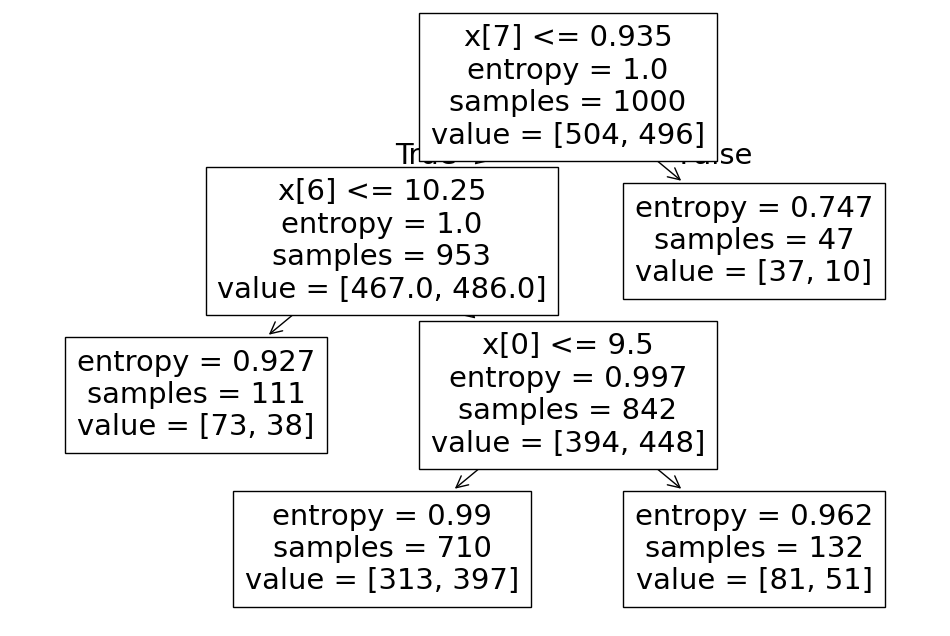

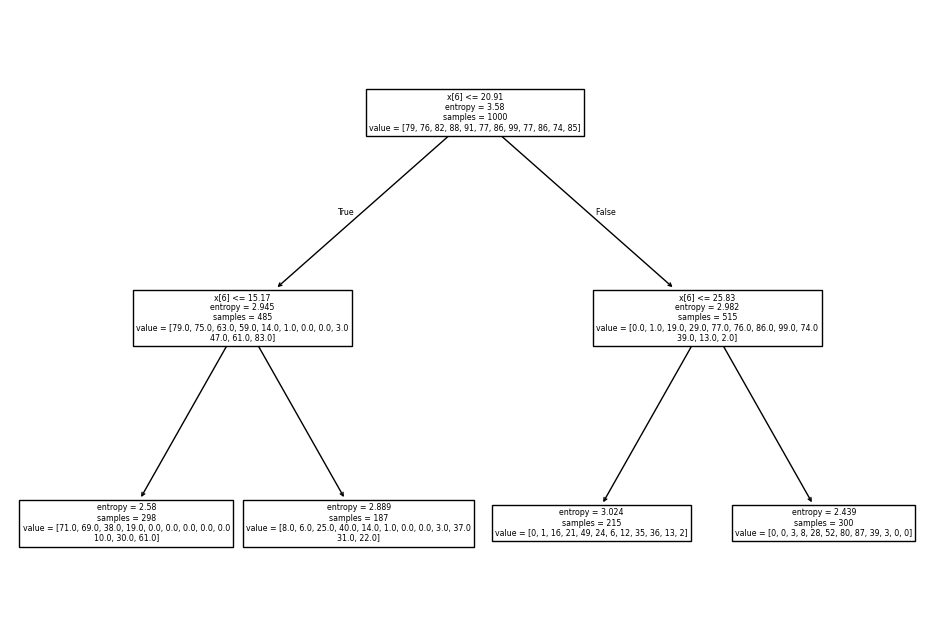

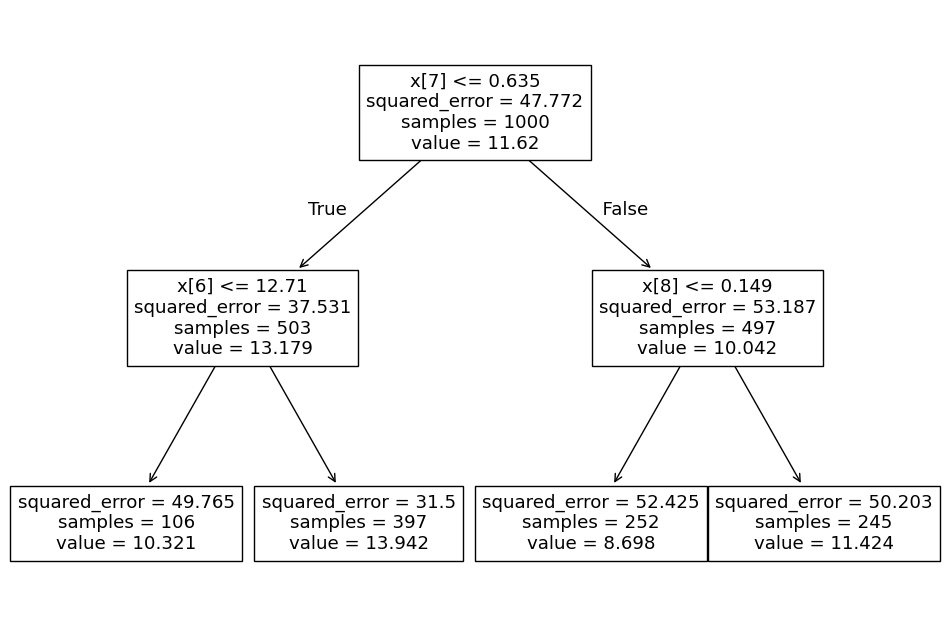

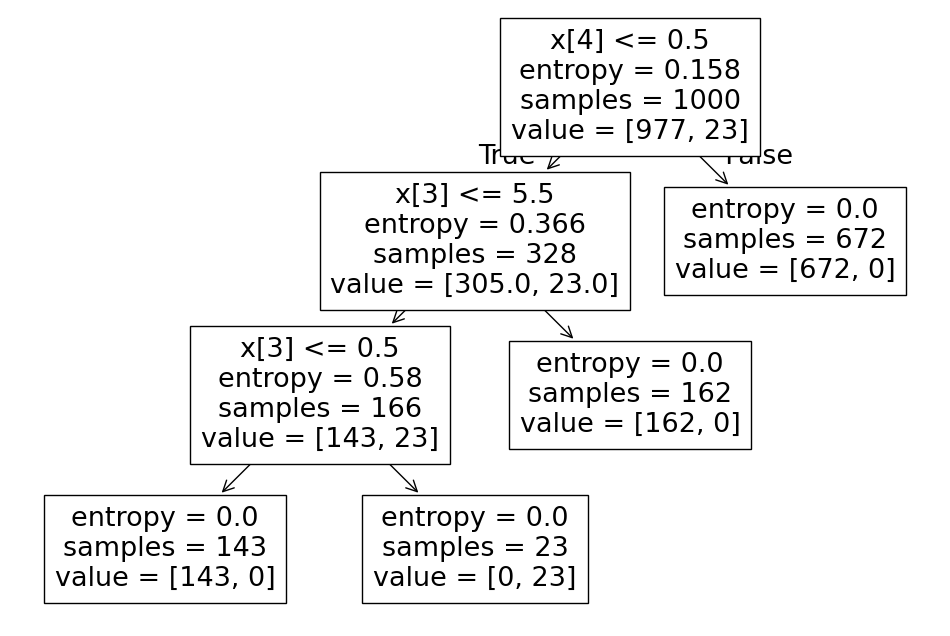

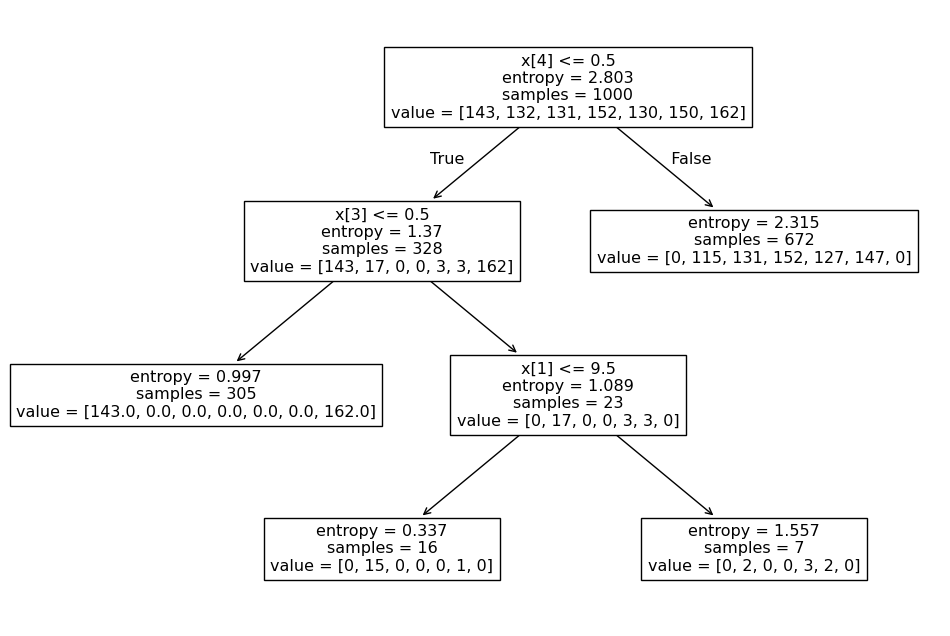

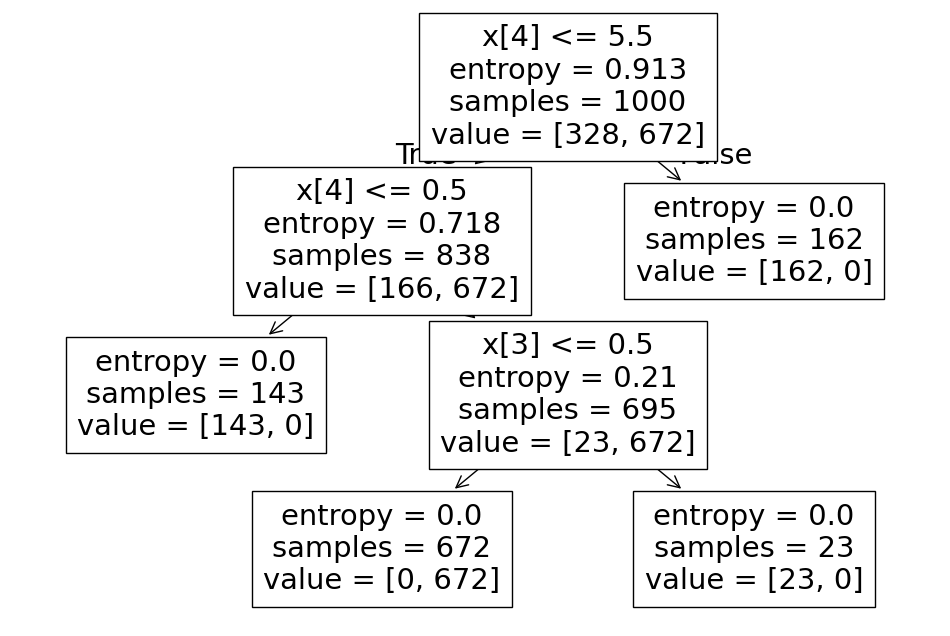

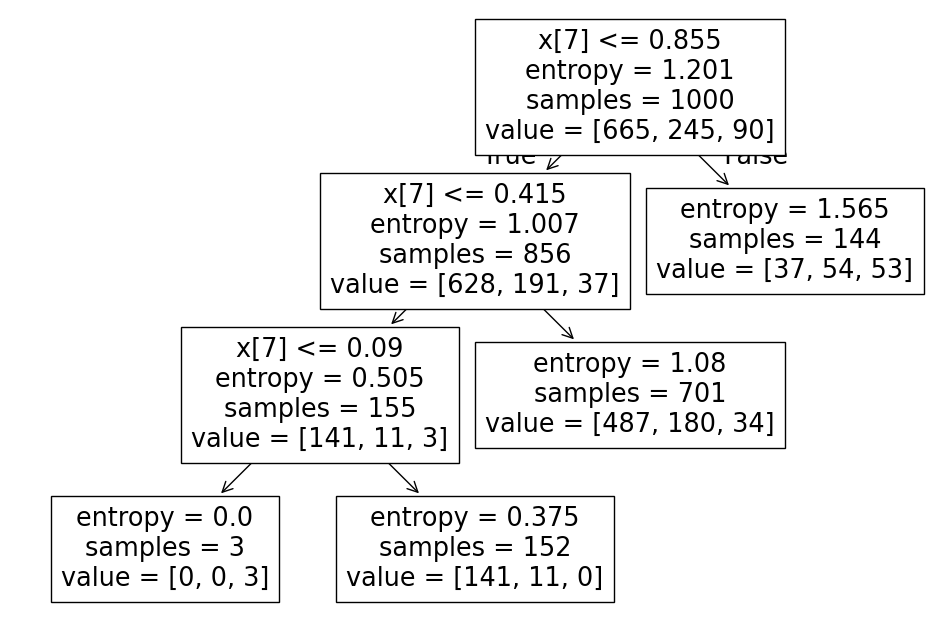

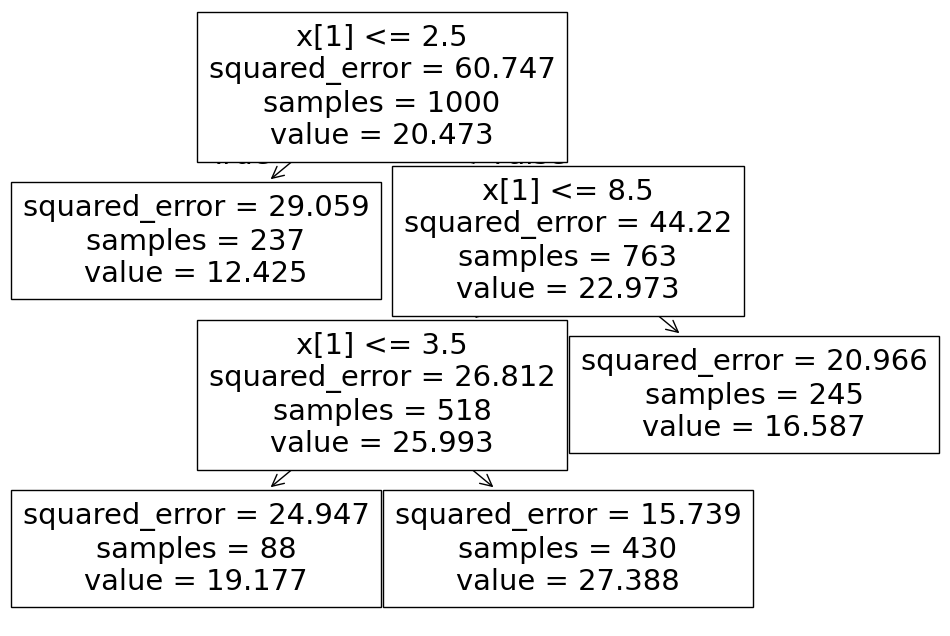

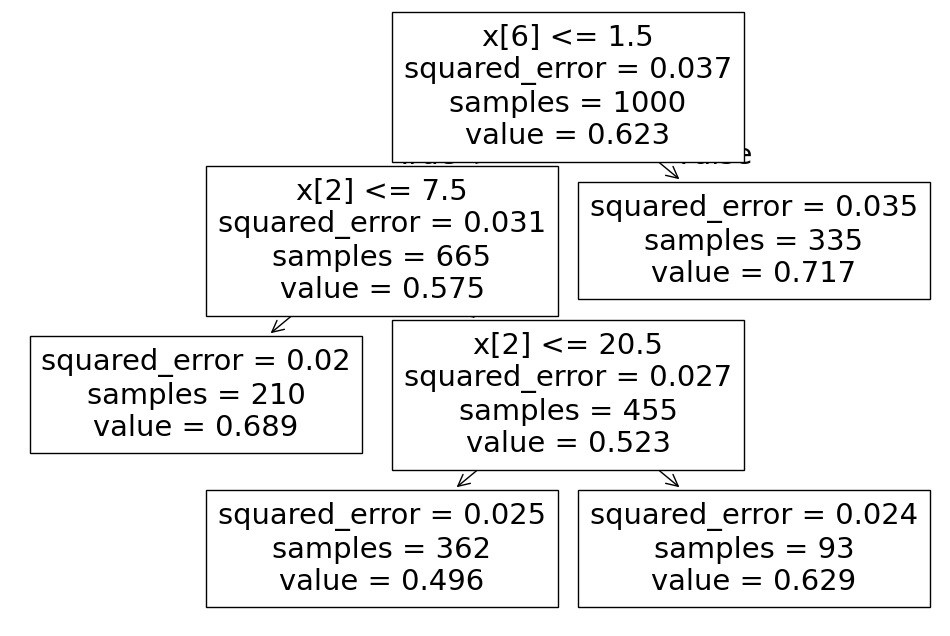

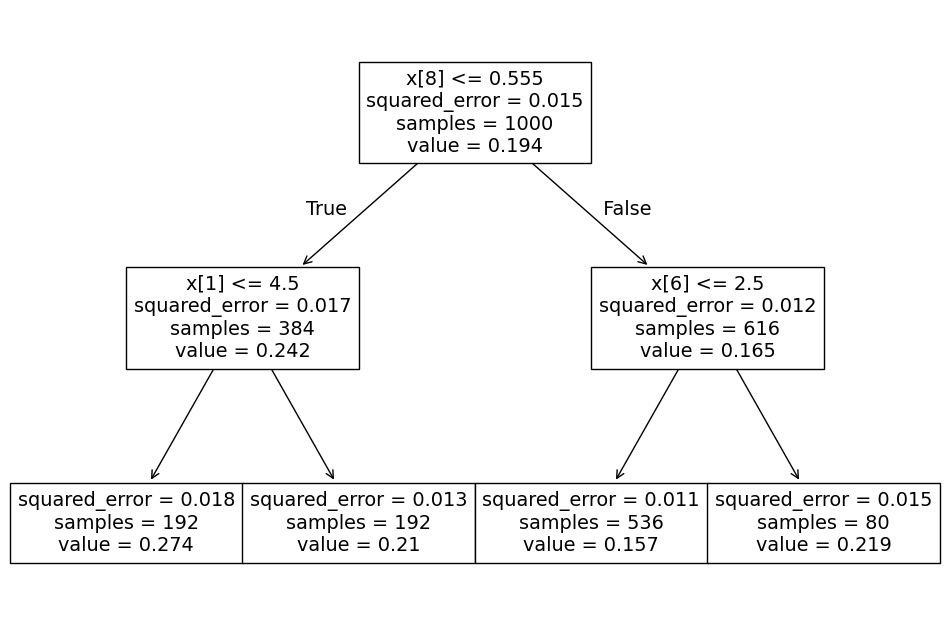

Feature 0: Binned Indices Sample = [2 2 2 2 2 2 3 2 0 2]
Feature 1: Binned Indices Sample = [0 3 3 0 1 2 3 1 0 0]
Feature 2: Binned Indices Sample = [1 3 3 1 3 0 2 3 2 2]
Feature 3: Binned Indices Sample = [0 0 0 1 1 0 1 0 0 0]
Feature 4: Binned Indices Sample = [0 0 0 1 1 0 1 0 0 0]
Feature 5: Binned Indices Sample = [2 2 2 0 0 2 0 2 2 2]
Feature 6: Binned Indices Sample = [3 0 0 1 1 1 0 1 0 1]
Feature 7: Binned Indices Sample = [3 0 1 3 3 0 1 3 3 1]
Feature 8: Binned Indices Sample = [3 0 1 1 1 3 2 3 0 0]
Feature 9: Binned Indices Sample = [1 2 2 2 2 2 2 2 2 2]


In [17]:
from granite.utils import create_bins_for_data_partition_tree

_, binned_features = create_bins_for_data_partition_tree(
    x=background,
    cat_feature_indices=cat_features,
    max_leaf_nodes=4,
    show_trees=True,
)
for i, bins in enumerate(binned_features):
    print(f"Feature {i}: Binned Indices Sample = {binned_features[i][:10]}")

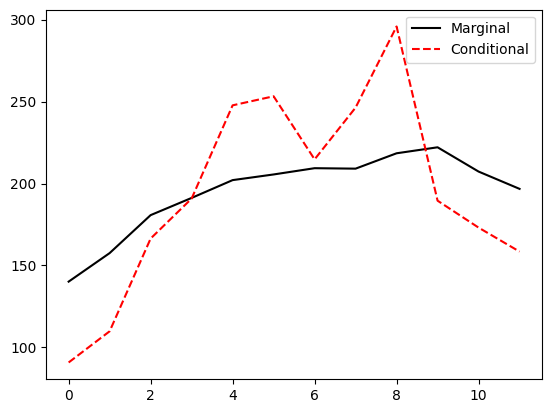

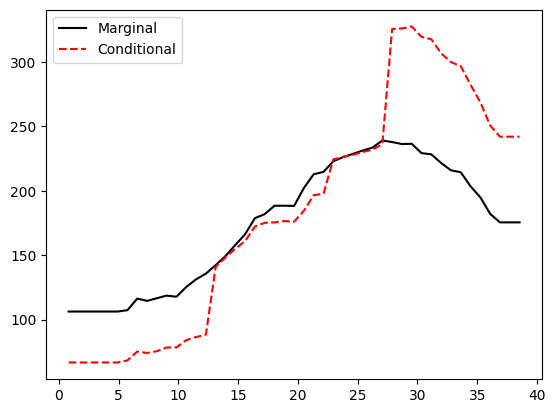

In [63]:
from granite.experiments import get_marginal_conditional_effects
# We investigate the 7th feature `temp`

for feature_id in [1, 7]:
    R = decomposition[(feature_id,)] + decomposition[()]

    marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_features[feature_id], R)
    argsort_x_i = np.argsort(background[:, feature_id])
    plt.plot(background[argsort_x_i, feature_id], marginal_effect[argsort_x_i], 'k-', label="Marginal")
    plt.plot(background[argsort_x_i, feature_id], conditional_effect[argsort_x_i], 'r--', label="Conditional")
    # plt.ylim(-6, 6)
    plt.legend()
    plt.show()

In [64]:
from granite.experiments import PDPvsMPlot


features_to_split_upon = [i for i in range(len(features)) if i != 7]
tree = PDPvsMPlot(
    features.select(features_to_split_upon),
    max_depth=3, save_losses=True, branching_per_node=3, alpha=0.005
)
tree.fit(background[:, features_to_split_upon], decomposition,
         U=[(1,), (7,)], binned_features=[binned_features[1], binned_features[7]]
)
tree.print(verbose=True)

Loss 0.0574
Samples 1000
If hr ≤ 6.0000:
|   Loss 0.0003
|   Samples 283
|   Region 0
else:
|   Loss 0.0367
|   Samples 717
|   If mnth ≤ 8.0000:
|   |   Loss 0.0282
|   |   Samples 541
|   |   If mnth ≤ 3.0000:
|   |   |   Loss 0.0076
|   |   |   Samples 224
|   |   |   Region 1
|   |   else:
|   |   |   Loss 0.0068
|   |   |   Samples 317
|   |   |   Region 2
|   else:
|   |   Loss 0.0027
|   |   Samples 176
|   |   Region 3
Final Loss 0.0174


In [46]:
larger_background = X[:4000]
_, binned_features = create_bins_for_data(
    x=larger_background,
    cat_feature_indices=cat_features,
    n_bins_numerical=5,
)
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()

(array([0], dtype=int32), array([4000]))


In [35]:
regional_decompositions = [[]] * tree.n_regions
regional_backgrounds = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions == r]
    regional_decompositions[r] = get_components_tree(model, regional_backgrounds[r], regional_backgrounds[r], features, anchored=True)

[##################################################] 100%[                                                  ] 0%

##################################################] 100%[                                                  ] 0%

##################################################] 100%[#                                                 ] 2%

################################################  ] 97%

##] 100%

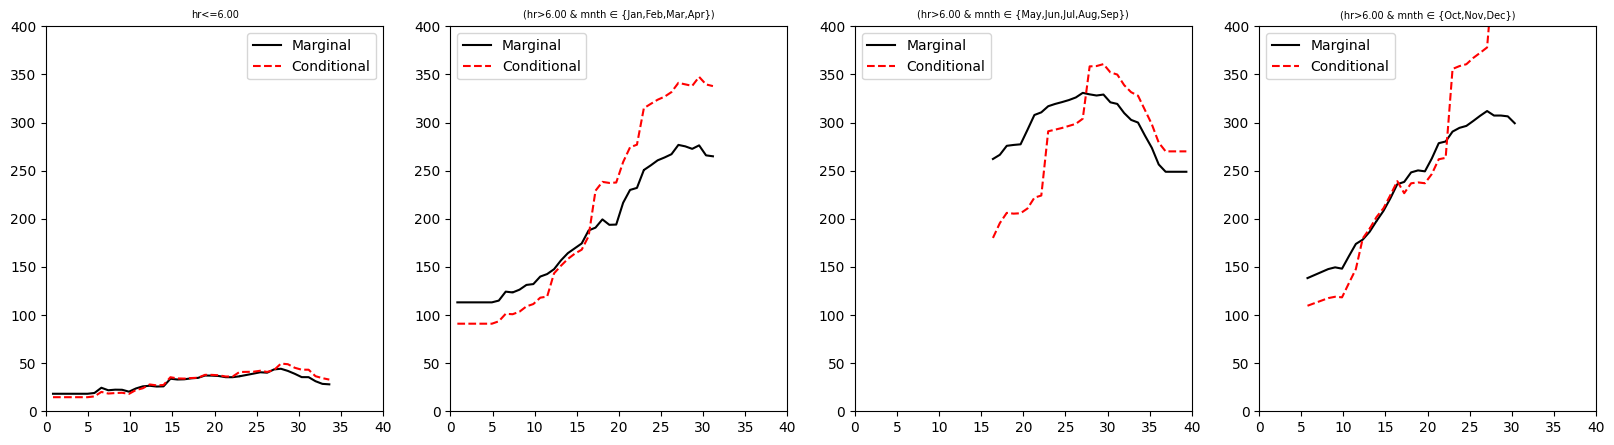

In [36]:
fig, axes = plt.subplots(1, tree.n_regions, figsize=(20, 5))
for r in range(tree.n_regions):
    R = regional_decompositions[r][(7,)] + regional_decompositions[r][()]
    X_region = regional_backgrounds[r]
    marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_features[7][regions==r], R)
    argsort_x_i = np.argsort(X_region[:, 7])
    axes[r].plot(X_region[argsort_x_i, 7], marginal_effect[argsort_x_i], 'k-', label="Marginal")
    axes[r].plot(X_region[argsort_x_i, 7], conditional_effect[argsort_x_i], 'r--', label="Conditional")
    axes[r].set_xlim(0, 40)
    axes[r].set_ylim(0, 400)
    axes[r].set_title(rules[r], fontsize=7)
    axes[r].legend()
plt.show()

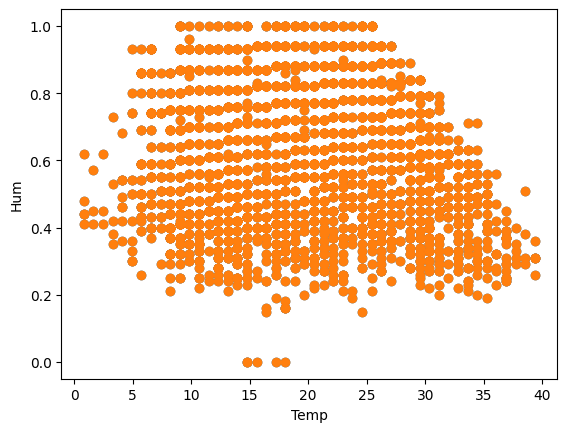

In [38]:
plt.scatter(larger_background[:, 7], larger_background[:, 8])
plt.xlabel("Temp")
plt.ylabel("Hum")
plt.show()